[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Multivariate_Occupancy_Lags.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 8 — Multivariate window method: room occupancy
- Still the window method, now with covariates: HVAC sensors (temperature, humidity, light, CO2) -> is the room occupied?
- Mostly unoccupied (imbalance); plot the target with CO2 and the story tells itself.
- Lag features from the past few minutes - and DROP lagged occupancy to avoid leakage (20 columns).
- 50/50 unshuffled split, sigmoid head -> ~97% and a mostly-diagonal confusion matrix.
-->


# Multivariate Occupancy Example
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Let's see if we can predict if it's a room is occupied as a function of environmental data.

Link: http://archive.ics.uci.edu/ml/datasets/Occupancy+Detection+

Same flow as before, just need to prep our data differently. For now, we ignore the time dimension but we could resample to a regular resolution.

Wow - also a nice example: https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/

In [1]:
# standard modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RNN-specific modules
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report,accuracy_score
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)


## Read in data
Check for missing values, make some plots.

In [2]:
# Dataset: UCI room-occupancy detection (Candanedo & Feldheim, 2016), originally from LuisM78's GitHub.
# We use the two real files - 8,143 minutes of training data (Feb 4-10) followed by 9,752 of test (Feb 11-18) -
# stacked in date order into one two-week series. (The 2-day datatest.txt slice was too short to learn from.)
base = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/"
df = pd.concat([pd.read_csv(base + "datatraining.txt"), pd.read_csv(base + "datatest2.txt")], ignore_index=True)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)   # chronological - never shuffle a time series
print(df.info())
df.head(n=15) # nice complete data! this will allow us to check our work later

<class 'pandas.DataFrame'>
RangeIndex: 17895 entries, 0 to 17894
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           17895 non-null  datetime64[us]
 1   Temperature    17895 non-null  float64       
 2   Humidity       17895 non-null  float64       
 3   Light          17895 non-null  float64       
 4   CO2            17895 non-null  float64       
 5   HumidityRatio  17895 non-null  float64       
 6   Occupancy      17895 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 978.8 KB
None


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.180,27.272000,426.0,721.250000,0.004793,1
1,2015-02-04 17:51:59,23.150,27.267500,429.5,714.000000,0.004783,1
2,2015-02-04 17:53:00,23.150,27.245000,426.0,713.500000,0.004779,1
3,2015-02-04 17:54:00,23.150,27.200000,426.0,708.250000,0.004772,1
4,2015-02-04 17:55:00,23.100,27.200000,426.0,704.500000,0.004757,1
5,2015-02-04 17:55:59,23.100,27.200000,419.0,701.000000,0.004757,1
6,2015-02-04 17:57:00,23.100,27.200000,419.0,701.666667,0.004757,1
7,2015-02-04 17:57:59,23.100,27.200000,419.0,699.000000,0.004757,1
8,2015-02-04 17:58:59,23.100,27.200000,419.0,689.333333,0.004757,1
9,2015-02-04 18:00:00,23.075,27.175000,419.0,688.000000,0.004745,1


In [3]:
# count of occupancy
df['Occupancy'].value_counts() # not perfectly balanced, but that's OK

Occupancy
0    14117
1     3778
Name: count, dtype: int64

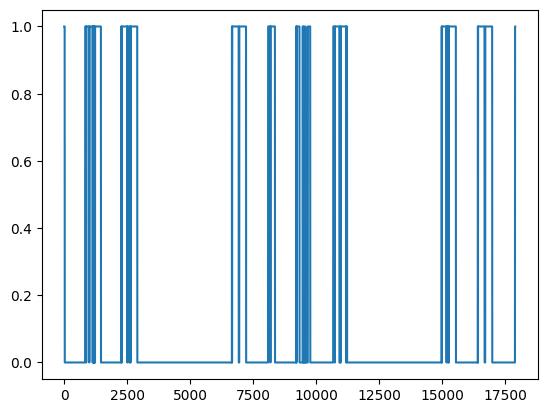

In [4]:
# visualize the data
df['Occupancy'].plot()
plt.show()

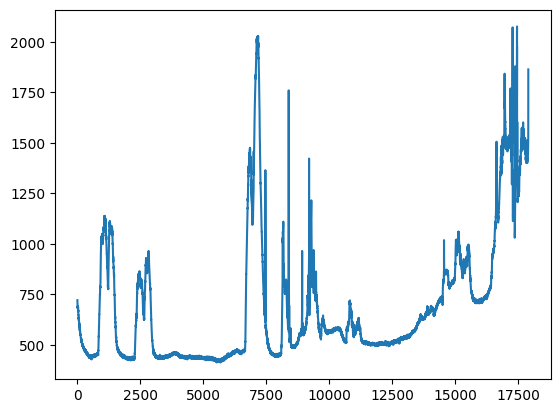

In [5]:
# visualize the data
df['CO2'].plot()
plt.show()

In [6]:
# drop the date column
df.drop(['date'], inplace=True, axis=1)
print(df.shape)
df.head()

(17895, 6)


,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.18,27.2720,426.0,721.25,0.004793,1
1,23.15,27.2675,429.5,714.00,0.004783,1
2,23.15,27.2450,426.0,713.50,0.004779,1
3,23.15,27.2000,426.0,708.25,0.004772,1
4,23.10,27.2000,426.0,704.50,0.004757,1


In [7]:
# link: https://machinelearningmastery.com/convert-time-series-supervised-learning-problem-python/

# we will probably drop the Y variable before running this

from pandas import DataFrame
from pandas import concat

def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
	"""
	Frame a time series as a supervised learning dataset.
	Arguments:
		data: Sequence of observations as a list or NumPy array.
		n_in: Number of lag observations as input (X).
		n_out: Number of observations as output (y).
		dropnan: Boolean whether or not to drop rows with NaN values.
	Returns:
		Pandas DataFrame of series framed for supervised learning.
	"""
	n_vars = 1 if type(data) is list else data.shape[1]
	df = DataFrame(data)
	cols, names = list(), list()
	# input sequence (t-n, ... t-1)
	for i in range(n_in, 0, -1):
		cols.append(df.shift(i))
		names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
	# forecast sequence (t, t+1, ... t+n)
	for i in range(0, n_out):
		cols.append(df.shift(-i))
		if i == 0:
			names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
		else:
			names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
	# put it all together
	agg = concat(cols, axis=1)
	agg.columns = names
	# drop rows with NaN values
	if dropnan:
		agg.dropna(inplace=True)
	return agg

In [8]:
# now let's prep the data - just processing X
tmp = series_to_supervised(df, n_in=3, n_out=1)

We can do some clean-up here and get rid of the y columns we don't need (unless we want to use prior timesteps!) It's your choice - do you want to use past values of y to make a prediction - or just use the X variables?

In [9]:
print(tmp.info())
tmp.head()

<class 'pandas.DataFrame'>
RangeIndex: 17892 entries, 3 to 17894
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   var1(t-3)  17892 non-null  float64
 1   var2(t-3)  17892 non-null  float64
 2   var3(t-3)  17892 non-null  float64
 3   var4(t-3)  17892 non-null  float64
 4   var5(t-3)  17892 non-null  float64
 5   var6(t-3)  17892 non-null  float64
 6   var1(t-2)  17892 non-null  float64
 7   var2(t-2)  17892 non-null  float64
 8   var3(t-2)  17892 non-null  float64
 9   var4(t-2)  17892 non-null  float64
 10  var5(t-2)  17892 non-null  float64
 11  var6(t-2)  17892 non-null  float64
 12  var1(t-1)  17892 non-null  float64
 13  var2(t-1)  17892 non-null  float64
 14  var3(t-1)  17892 non-null  float64
 15  var4(t-1)  17892 non-null  float64
 16  var5(t-1)  17892 non-null  float64
 17  var6(t-1)  17892 non-null  float64
 18  var1(t)    17892 non-null  float64
 19  var2(t)    17892 non-null  float64
 20  var3(t)    17892 

,var1(t-3),var2(t-3),var3(t-3),var4(t-3),var5(t-3),var6(t-3),var1(t-2),var2(t-2),var3(t-2),var4(t-2),...,var3(t-1),var4(t-1),var5(t-1),var6(t-1),var1(t),var2(t),var3(t),var4(t),var5(t),var6(t)
3,23.18,27.2720,426.0,721.25,0.004793,1.0,23.15,27.2675,429.5,714.00,...,426.0,713.500000,0.004779,1.0,23.15,27.2,426.0,708.250000,0.004772,1
4,23.15,27.2675,429.5,714.00,0.004783,1.0,23.15,27.2450,426.0,713.50,...,426.0,708.250000,0.004772,1.0,23.10,27.2,426.0,704.500000,0.004757,1
5,23.15,27.2450,426.0,713.50,0.004779,1.0,23.15,27.2000,426.0,708.25,...,426.0,704.500000,0.004757,1.0,23.10,27.2,419.0,701.000000,0.004757,1
6,23.15,27.2000,426.0,708.25,0.004772,1.0,23.10,27.2000,426.0,704.50,...,419.0,701.000000,0.004757,1.0,23.10,27.2,419.0,701.666667,0.004757,1
7,23.10,27.2000,426.0,704.50,0.004757,1.0,23.10,27.2000,419.0,701.00,...,419.0,701.666667,0.004757,1.0,23.10,27.2,419.0,699.000000,0.004757,1


In [10]:
# here are X and y
y = tmp['var6(t)']
X = tmp.drop(['var6(t)'], axis=1)
print(X.shape, y.shape)

(17892, 23) (17892,)


In [11]:
# for fun, you can delete previous occupancy
del X['var6(t-1)']
del X['var6(t-2)']
del X['var6(t-3)']
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 17892 entries, 3 to 17894
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   var1(t-3)  17892 non-null  float64
 1   var2(t-3)  17892 non-null  float64
 2   var3(t-3)  17892 non-null  float64
 3   var4(t-3)  17892 non-null  float64
 4   var5(t-3)  17892 non-null  float64
 5   var1(t-2)  17892 non-null  float64
 6   var2(t-2)  17892 non-null  float64
 7   var3(t-2)  17892 non-null  float64
 8   var4(t-2)  17892 non-null  float64
 9   var5(t-2)  17892 non-null  float64
 10  var1(t-1)  17892 non-null  float64
 11  var2(t-1)  17892 non-null  float64
 12  var3(t-1)  17892 non-null  float64
 13  var4(t-1)  17892 non-null  float64
 14  var5(t-1)  17892 non-null  float64
 15  var1(t)    17892 non-null  float64
 16  var2(t)    17892 non-null  float64
 17  var3(t)    17892 non-null  float64
 18  var4(t)    17892 non-null  float64
 19  var5(t)    17892 non-null  float64
dtypes: float64(20)
me

In [12]:
# take a peak at what it did
print(X.shape) # see how X has blown up?
print(y.shape)

# scroll up and make sure you understand this!
# y is a function of X (the previous n_steps observations!)

(17892, 20)
(17892,)


In [13]:
# split the data into train and test partitions
# we will use 50% of the data for train, and 50% for validation
train_pct_index = int(0.5 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = y[:train_pct_index], y[train_pct_index:]

# pretty slick way of splitting your data using slicing!
# notice how we didn't do any shuffling (we don't want temporal leakage! keeps time series intact)

In [14]:
# check the shape to be sure
print(X.shape, X_train.shape, X_test.shape)
print(y.shape, y_train.shape, y_test.shape)

# verify that this all adds up!

(17892, 20) (8946, 20) (8946, 20)
(17892,) (8946,) (8946,)


In [15]:
# if we wanted to, we could do some scaling/normalization here, would not hurt!
# link: https://datascience.stackexchange.com/questions/12321/whats-the-difference-between-fit-and-fit-transform-in-scikit-learn-models

# do we need to fit this twice?!

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
scaler.transform(X_train)
scaler.transform(X_test)

array([[-0.05922046, -0.25400435, -0.61321124, ..., -0.61269376,
        -0.13930594, -0.22977043],
       [-0.05922046, -0.3201862 , -0.61321124, ..., -0.61269376,
        -0.12942762, -0.33785018],
       [-0.05922046, -0.28196851, -0.61321124, ..., -0.61269376,
        -0.12448846, -0.33694965],
       ...,
       [ 0.15755558,  0.27125575,  1.60307963, ...,  1.56707559,
         3.01187673,  0.39229541],
       [ 0.15755558,  0.32718407,  1.59793444, ...,  1.54262717,
         3.37572802,  0.44327868],
       [ 0.20796861,  0.33231083,  1.565777  , ...,  1.49244358,
         4.13965109,  0.49256419]], shape=(8946, 20))

# DNN one layer model

In [16]:
# now let's build a model

# define model
model = Sequential()
model.add(Dense(30, input_shape=(X.shape[1],), activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])
model.summary()

es = EarlyStopping(monitor='val_acc', mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)


# fit model (uses early stopping)
model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 661 (2.58 KB)

 Trainable params: 661 (2.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 5:15 3s/step - acc: 0.7500 - loss: 123.0194

 15/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7521 - loss: 86.3216  

 30/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7922 - loss: 51.4479

 46/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8210 - loss: 35.4834

 63/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8450 - loss: 27.3287

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8569 - loss: 22.8288

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8667 - loss: 19.3738

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8754 - loss: 16.7517

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - acc: 0.8779 - loss: 16.1983 - val_acc: 0.9369 - val_loss: 0.9828


Epoch 2/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - acc: 0.9688 - loss: 0.1737

 21/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9353 - loss: 1.0753 

 41/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9455 - loss: 0.9035

 61/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9457 - loss: 1.0255

 80/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9418 - loss: 1.0574

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9420 - loss: 1.0386

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9434 - loss: 1.0005 - val_acc: 0.8799 - val_loss: 0.9501


Epoch 3/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - acc: 0.9688 - loss: 0.0482

 18/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9523 - loss: 0.6898 

 32/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9570 - loss: 0.7442

 50/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9566 - loss: 0.6837

 71/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9531 - loss: 0.9163

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9493 - loss: 0.8637

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9514 - loss: 0.8467

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9514 - loss: 0.8467 - val_acc: 0.8983 - val_loss: 0.7796


Epoch 4/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.9844 - loss: 0.0353

 23/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9558 - loss: 0.6575 

 46/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9572 - loss: 0.5696

 66/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9534 - loss: 0.7052

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9491 - loss: 0.7290

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9481 - loss: 0.6957

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9475 - loss: 0.6957 - val_acc: 0.8698 - val_loss: 0.9577


Epoch 5/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - acc: 0.9531 - loss: 0.1280

 16/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9453 - loss: 0.5422   

 30/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9547 - loss: 0.4874

 46/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9592 - loss: 0.4256

 63/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9581 - loss: 0.5418

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9591 - loss: 0.5707

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9592 - loss: 0.5395

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9590 - loss: 0.5387

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9582 - loss: 0.5258

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.9585 - loss: 0.5221 - val_acc: 0.8665 - val_loss: 0.8836


Epoch 6/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - acc: 0.9688 - loss: 0.0999

 17/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9559 - loss: 0.4306   

 34/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9632 - loss: 0.3854

 50/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9672 - loss: 0.3355

 68/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9639 - loss: 0.4221

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9632 - loss: 0.4392

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9614 - loss: 0.4260

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9612 - loss: 0.4133 - val_acc: 0.8654 - val_loss: 0.8004


Epoch 7/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 13s 120ms/step - acc: 0.9844 - loss: 0.0941

 18/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9601 - loss: 0.3531   

 35/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9688 - loss: 0.2987

 50/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9712 - loss: 0.2620

 69/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9681 - loss: 0.3266

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9673 - loss: 0.3417

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9665 - loss: 0.3271

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9667 - loss: 0.3164 - val_acc: 0.8659 - val_loss: 0.6802


Epoch 8/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - acc: 0.9844 - loss: 0.0742

 19/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9613 - loss: 0.2793 

 38/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9716 - loss: 0.2203

 59/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9727 - loss: 0.1964

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9706 - loss: 0.2725

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9706 - loss: 0.2589

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9705 - loss: 0.2473

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9705 - loss: 0.2450 - val_acc: 0.8732 - val_loss: 0.5124


Epoch 9/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - acc: 0.9844 - loss: 0.0615

 18/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9635 - loss: 0.2280 

 33/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9711 - loss: 0.1859

 48/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9749 - loss: 0.1570

 66/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9735 - loss: 0.2085

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9706 - loss: 0.2220

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9712 - loss: 0.2039

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9723 - loss: 0.1951 - val_acc: 0.9011 - val_loss: 0.3179


Epoch 10/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - acc: 0.9844 - loss: 0.0402

 20/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9664 - loss: 0.1686   

 37/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9742 - loss: 0.1318

 54/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9742 - loss: 0.1304

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9741 - loss: 0.1849

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9713 - loss: 0.1794

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9716 - loss: 0.1713

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9718 - loss: 0.1665 - val_acc: 0.8961 - val_loss: 0.2707


Epoch 11/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 1:17 700ms/step - acc: 0.9844 - loss: 0.0353

 18/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9566 - loss: 0.1675    

 35/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9683 - loss: 0.1241

 51/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9721 - loss: 0.1166

 65/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9707 - loss: 0.1441

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9680 - loss: 0.1639

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9680 - loss: 0.1594

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9693 - loss: 0.1532 - val_acc: 0.8793 - val_loss: 0.3235


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 1.


  1/280 ━━━━━━━━━━━━━━━━━━━━ 27s 100ms/step

 36/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step   

 75/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

117/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

158/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

200/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

237/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

276/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[[5.8733908e-14]
 [8.1524671e-14]
 [2.5832247e-13]
 ...
 [9.9520558e-01]
 [1.0000000e+00]
 [1.0000000e+00]]
[[0.]
 [0.]
 [0.]
 ...
 [1.]
 [1.]
 [1.]]
[[6920  191]
 [ 315 1520]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      7111
           1       0.89      0.83      0.86      1835

    accuracy                           0.94      8946
   macro avg       0.92      0.90      0.91      8946
weighted avg       0.94      0.94      0.94      8946



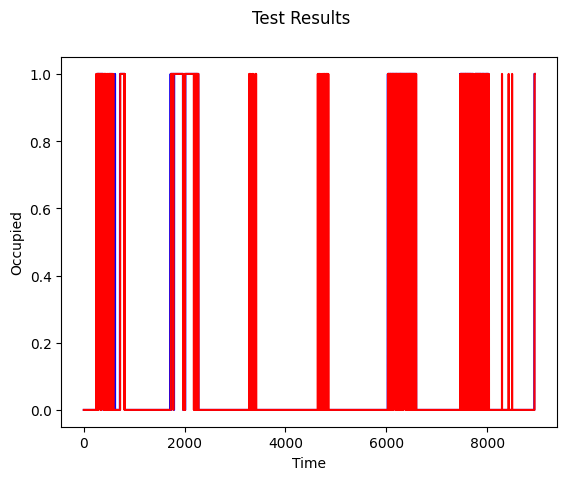

In [17]:
# put it all together for other models

# make a prediction
pred = model.predict(X_test)# the pred
print(pred) # round them!

pred = np.round(pred,0)
print(pred) # run all if you get an error...

# confusion matrix - put this at the top!
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print(confusion_matrix(y_test, pred)) # looks pretty good!
print(classification_report(y_test, pred))

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Occupied')
plt.show()

## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [18]:
from keras.models import load_model

model.save('Multivariate_Occupancy_Lags.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('Multivariate_Occupancy_Lags.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.76 KB)

 Trainable params: 661 (2.58 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,324 (5.18 KB)

Think about what a baseline model would be... is it possible to predict occupancy without previous Y data (just use X?) To do this, you would just need to delete some of the variables in tmp before splitting, then re-run the model.